In [126]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, restoration, img_as_float, img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os
import glob
import cv2
import pandas as pd
import time # to track the execution time
import shutil

In [110]:
# define the global variable
base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
BLUR_PATH = os.path.join(base_dir, "..", "data", "blur", "images")
SHARP_PATH = os.path.join(base_dir, "..", "data", "sharp", "images")

### Step 1. Detecting Image Blur Intensity

identify blur intensities for all images, then classified them

In [111]:
# define threshold for blur intensity
low_freq_threshold = 30    # Distance in pixels. Assumption
high_freq_threshold = 100  # Distance in pixels. Assumption

def calculate_blur_intensity(img_path, low_point=30, high_point=100):
    img = cv2.imread(img_path)
    height, width = img.shape[0:2]
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # transform into gray
    fft_2d = np.fft.fft2(img_gray) # implement Fourier Transformation
    fft_shifted = np.fft.fftshift(fft_2d)

    # calculate magnitude
    magnitude_spectrum = np.abs(fft_shifted)
    log_magnitude = np.log1p(magnitude_spectrum)

    # calculate blur score by using radial energy profile
    cy, cx = height // 2, width // 2
    y, x = np.ogrid[:height, : width]
    radial_distance = np.sqrt((x - cx)**2 + (y - cy)**2)

    # Define frequency rings:
    # - Low frequencies: close to center (distance 0-30)
    # - High frequencies: far from center (distance > 100)
    # These thresholds can be tuned based on your images
    
    # Create masks for different frequency regions
    low_freq_mask = radial_distance <= low_point
    high_freq_mask = radial_distance >= high_point
    
    # Sum up energy (magnitude) in each frequency region
    low_freq_energy = np.sum(magnitude_spectrum[low_freq_mask])
    high_freq_energy = np.sum(magnitude_spectrum[high_freq_mask])
    total_energy = np.sum(magnitude_spectrum)

    blur_score = (high_freq_energy / total_energy)* 1000 # using only high frequency energy

    return blur_score


In [112]:
# calculate blur intensities for all blur image
image_extensions = ["*.png", "*.jpg", "*.jpeg"]
blur_paths = []
result_deblur_list = []

# get the blur images path
for e in image_extensions:
    blur_paths.extend(glob.glob(os.path.join(BLUR_PATH, e)))
# print(f"Found blur images:{len(blur_paths)}")

blur_int_list = []
for i in blur_paths:
    blur_score = calculate_blur_intensity(i)
    blur_int_list.append(blur_score) 

blur_int_pair = pd.DataFrame({'blur_paths':blur_paths, 'blur_int':blur_int_list}) # 3 mins

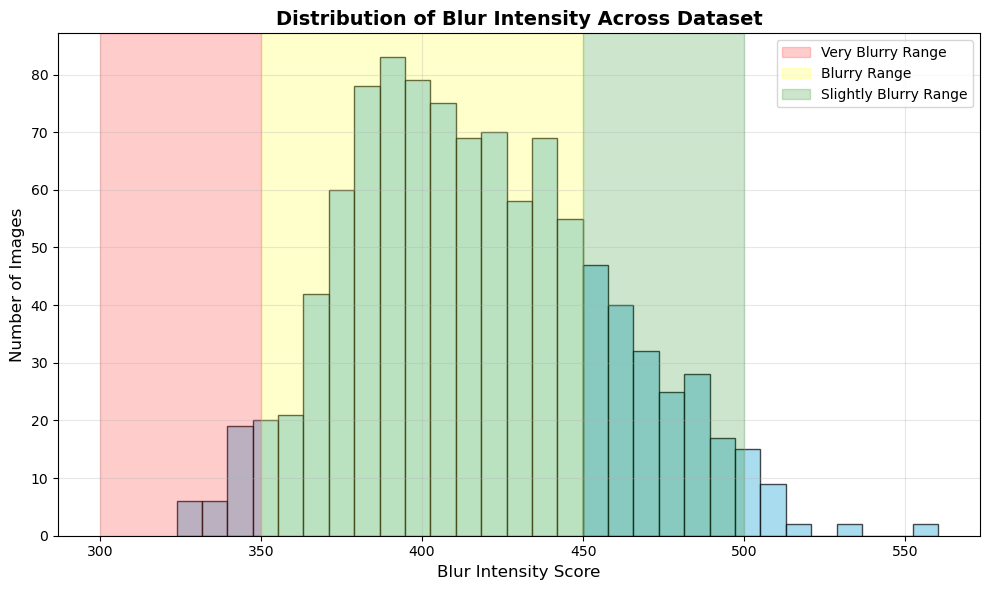

In [113]:
# make script for histogram in matplotlib by using blur_int_pair['blur_int']
plt.figure(figsize=(10, 6))
plt.hist(blur_int_pair['blur_int'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Blur Intensity Score', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Blur Intensity Across Dataset', fontsize=14, fontweight='bold')
plt.axvspan(300,350, alpha=0.2, color='red', label='Very Blurry Range')
plt.axvspan(350,450, alpha=0.2, color='yellow', label='Blurry Range')
plt.axvspan(450,500, alpha=0.2, color='green', label='Slightly Blurry Range')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From the graphic above, we make 3 categories:
- Blur intensity 300 - 350: very blurry
- Blur intensity 351 - 450: blurry
- Blur intensity > 450: slightly blurry

We take each of the categories 2 images as an example

In [ ]:

cat_very_blur = blur_int_pair.nsmallest(n=2, columns=['blur_int']) # very blurry category
cat_very_blur_img = [os.path.basename(path) for path in cat_very_blur['blur_paths']]

cat_blur = blur_int_pair[blur_int_pair['blur_int'].between(350,450)].nsmallest(n=2, columns=['blur_int']) # blur category
cat_blur_img = [os.path.basename(path) for path in cat_blur['blur_paths']]

cat_slight_blur = blur_int_pair[blur_int_pair['blur_int'].between(450,500)].nsmallest(n=2, columns=['blur_int']) # slightly blur category
cat_slight_blur_img = [os.path.basename(path) for path in cat_slight_blur['blur_paths']]

print(f"The images for very blur category: {cat_very_blur_img}.")
print(f"The images for blur category: {cat_blur_img}")
print(f"The images for slightly blur category: {cat_slight_blur_img}")

The images for very blur category: ['000168.png', '000129.png'].
The images for blur category: ['000014.png', '000116.png']
The images for slightly blur category: ['000546.png', '000311.png']


### Step 2. Build and Implement Wiener Filter

Now, we will build and implement deblurring to these 6 images and see the comparison.

First, we will build a Wiener Filter

In [ ]:
# define the blur kernesl (PSF))
# PSF: Point Spread Function.
# Kernel size: the size of the PSF kernel
# Sigma: to control the amount of blurring. A larger sigma will result in a blurrier image.
# Using Gaussian kernel as the PSF for Wiener deblurring

def gaussian_kernel(size=15, power=3):
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * power**2))
    return kernel / kernel.sum()


In [ ]:
# Build wiener filter function
def wiener_filter(blur_img, psf, wiener_balance = 0.15): 
    deblurred_channel = []
    for ch in range(3):
        restored_ch = restoration.wiener(blur_img[:,:,ch], psf, balance=wiener_balance) # perform it on every channel
        deblurred_channel.append(restored_ch)
    
    deblurred = np.stack(deblurred_channel, axis=-1)
    deblurred = np.clip(deblurred, 0, 1)

    return deblurred

In [ ]:
# Build function to implement PSF and wiener filter
kernel_size = 15 # assumption
sigma = 3 # assumption
wiener_balance = 0.15 # assumption

def deblur_wiener(blur_img, size=15, power=3, balance=0.15):
    # get the image
    blurred_raw = io.imread(blur_img) # to convert the image to a floating-point representation in the range [0, 1]
    blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)

    # call gaussian kernel
    psf = gaussian_kernel(size=size, power=power) # make gaussian kernel
    # call wiener filter
    result = wiener_filter(blurred, psf,wiener_balance=balance)

    return result # the result shape is 720x1280x3


C:\Users\qunto\AppData\Local\Temp\ipykernel_32320\343661888.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


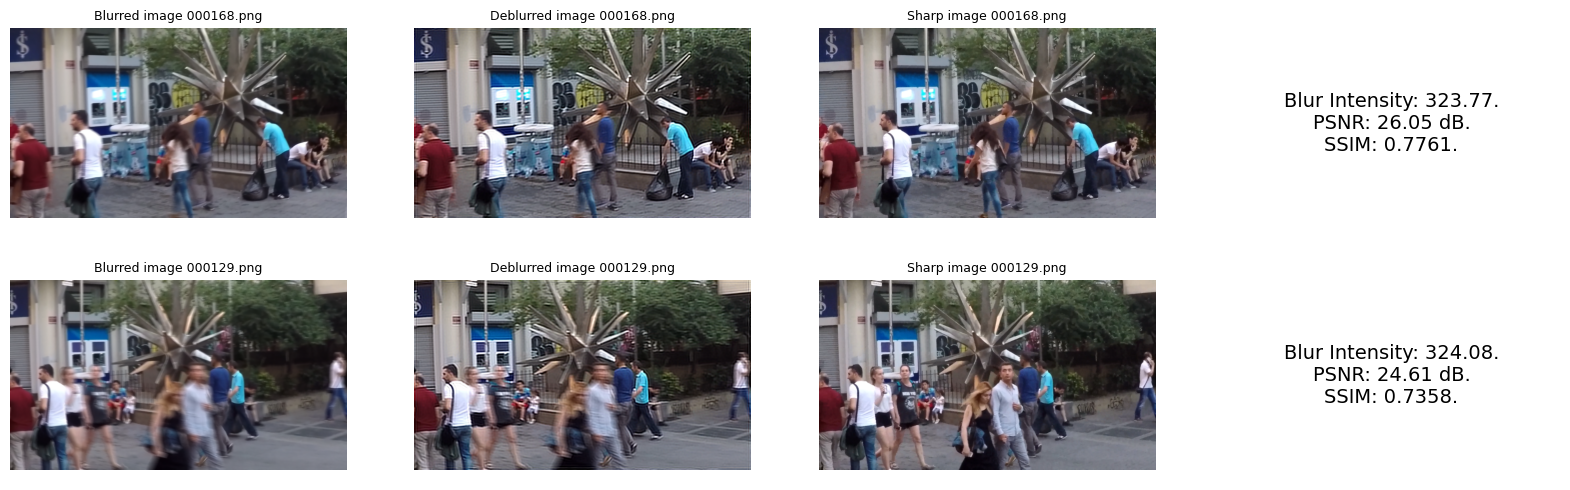

In [ ]:
# Build function to call the wiener filter, calculate PSNR and SSIM, and plot them. Use it on each of categories.

def compare_and_plot(target_images, blur_int_data,size=15, power=3, balance=0.15):
    """
    blur_int_data: dataframe from list of 

    """
    # 1. get the blurred image
    blurred_list = []
    for i in target_images:        
        address_blur = os.path.join(BLUR_PATH,i) # get address of all images
        blurred_raw = io.imread(address_blur) # to convert the image to a floating-point representation in the range [0, 1]
        blurred = img_as_float(blurred_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)
        blurred_list.append(blurred)
    
    # 2. implement deblur process using wiener filter
    deblur_result_list = []
    for i in target_images:
        img_path = os.path.join(BLUR_PATH,i)
        deblur_img = deblur_wiener(img_path, size=size, power=power, balance=balance)
        deblur_result_list.append(deblur_img)
    
    # 3. get the sharp images
    sharp_list = []
    for i in target_images:
        address_sharp = os.path.join(SHARP_PATH,i)
        sharp_raw = io.imread(address_sharp) # to convert the image to a floating-point representation in the range [0, 1]
        sharp = img_as_float(sharp_raw) # to convert the image back to an unsigned 8-bit integer format (0-255)
        sharp_list.append(sharp)

    # 5. get the blur intensity and calculate the psnr and ssim
    blur_psnr_ssim_val = []
    for i in range(len(target_images)):
        img_path = os.path.join(BLUR_PATH,target_images[i])
        blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])
        psnr_val = psnr(deblur_result_list[i], sharp_list[i], data_range=1.0)
        ssim_val = ssim(deblur_result_list[i], sharp_list[i], channel_axis=2, data_range=1.0)
        res_blur_psnr_ssim = f"Blur Intensity: {blur_int_val:.2f}.\nPSNR: {psnr_val:.2f} dB.\nSSIM: {ssim_val:.4f}."
        blur_psnr_ssim_val.append(res_blur_psnr_ssim)

    # 6. plot all of the data
    fig, axes = plt.subplots(len(target_images), 4, figsize=(len(target_images)*10, len(target_images)*3), squeeze=False)
    for x in range(len(target_images)):
        # show the images of blurred, deblurre, and sharp
        axes[x][0].imshow(blurred_list[x])
        axes[x][1].imshow(deblur_result_list[x])
        axes[x][2].imshow(sharp_list[x])    
        axes[x][3].text(0.5, 0.5, blur_psnr_ssim_val[x], transform=axes[x, 3].transAxes,
                ha='center', va='center', fontsize=14, color='black')
        
        # show the title
        axes[x][0].set_title(f"Blurred image {target_images[x]}", fontsize=9)
        axes[x][1].set_title(f"Deblurred image {target_images[x]}", fontsize=9)
        axes[x][2].set_title(f"Sharp image {target_images[x]}", fontsize=9)

        # set off the axis
        axes[x][0].axis("off")
        axes[x][1].axis("off")
        axes[x][2].axis("off")
        axes[x][3].axis("off")

    plt.show()

# compare and plot for very blurry category
compare_and_plot(cat_very_blur_img, blur_int_pair)

C:\Users\qunto\AppData\Local\Temp\ipykernel_32320\343661888.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


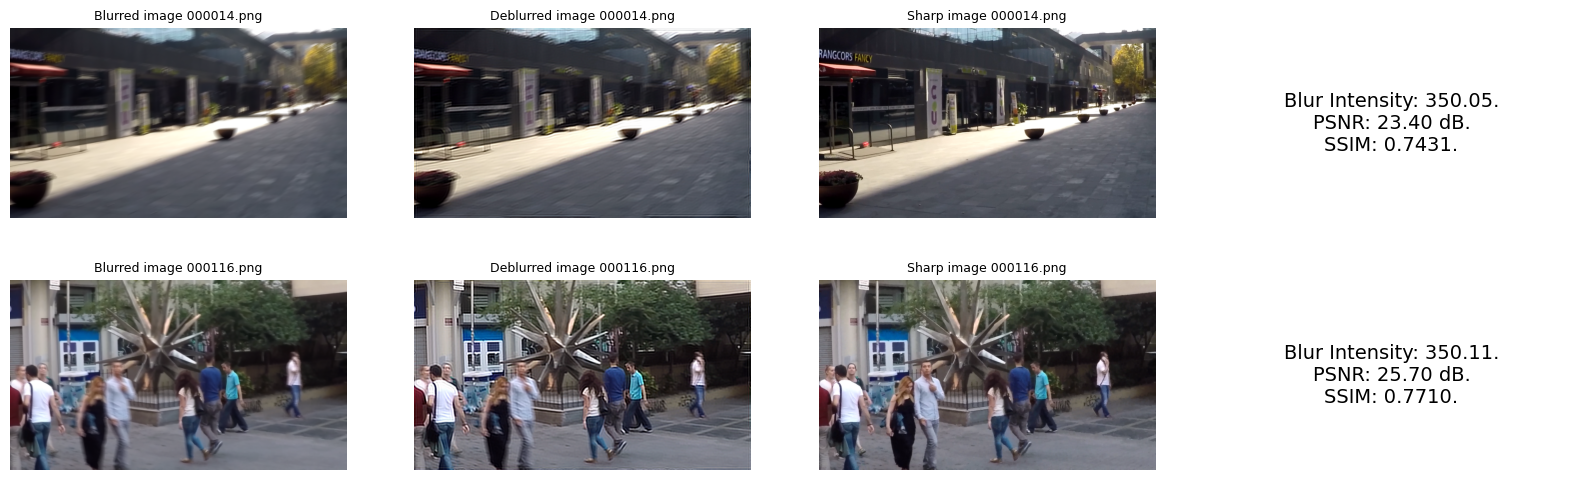

In [119]:
# compare and plot for blurry category
compare_and_plot(cat_blur_img, blur_int_pair)

C:\Users\qunto\AppData\Local\Temp\ipykernel_32320\343661888.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  blur_int_val = float(blur_int_data[blur_int_data['blur_paths'] == img_path]['blur_int'])


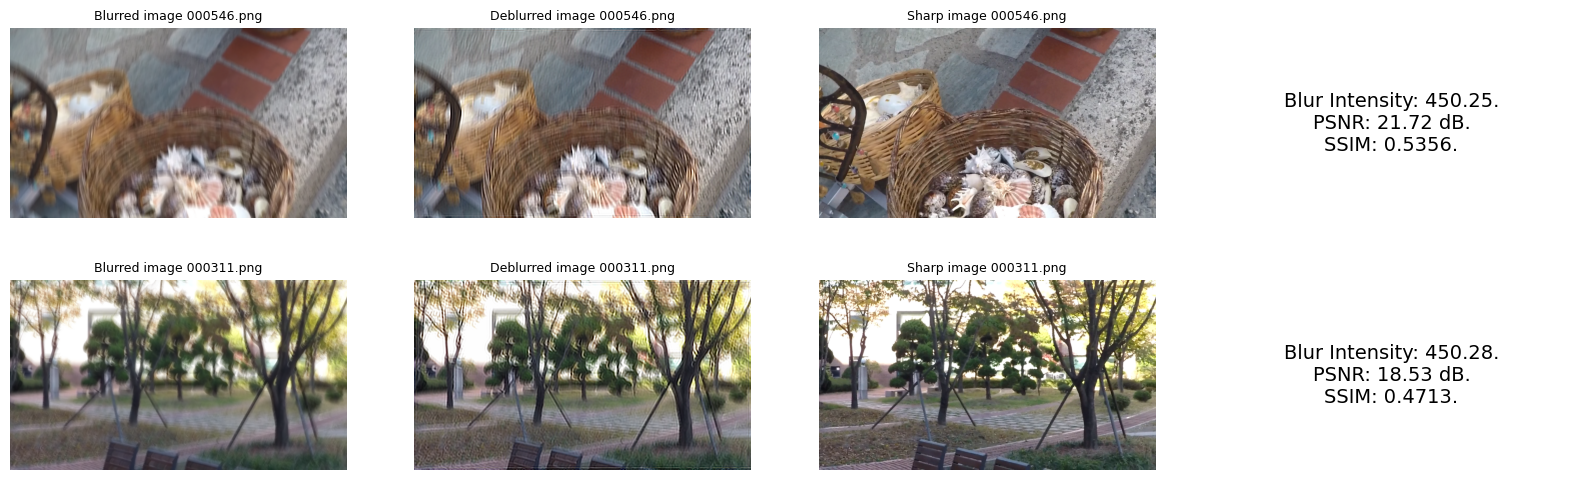

In [120]:
# compare and plot for slightly blurry category
compare_and_plot(cat_slight_blur_img, blur_int_pair)

Make conclusion about the deblur process

abcdef

### Step 3. Implement all Wiener Filter deblurring to all images and store the new image

In [132]:
# function to deblur all blurred images and store it to a new folder
def deblur_wiener_and_store(blur_path, size=15, power=3, balance=0.15):
    """
    """
    image_extensions = ["*.png", "*.jpg", "*.jpeg"]
    blur_paths = []

    # Define the output folder path
    output_folder = os.path.join(base_dir, "..", "data", "deblur_wiener", "images") # change this accordingly

    # Check if folder exists, create it if it doesn't
    # os.makedirs(output_folder, exist_ok=True)

    # Remove the folder if it exists, then create a fresh one
    if os.path.exists(output_folder):
        for filename in os.listdir(output_folder):
            file_path = os.path.join(output_folder, filename)
            if os.path.isfile(file_path):
                os.unlink(file_path)
    else:
        os.makedirs(output_folder, exist_ok=True)

    # get the blur images path
    for e in image_extensions:
        blur_paths.extend(glob.glob(os.path.join(blur_path, e)))
    # print(f"Found blur images:{len(blur_paths)}")

    # perform deblur process using wiener filter and save it to designated  folder
    for i in blur_paths:
        deblur_img = deblur_wiener(i, size=size, power=power, balance=balance)
        # Construct the full file path for saving
        output_path = os.path.join(output_folder, os.path.basename(i))

        # Convert deblurred image to 8-bit format and save
        deblur_img_uint8 = img_as_ubyte(deblur_img)
        io.imsave(output_path, deblur_img_uint8)
    
    print(f"Successully deblur {len(blur_paths)} images!")        

In [ ]:
# Before calling the function
start_time = time.perf_counter()

deblur_wiener_and_store(BLUR_PATH, size=15, power=3, balance=0.15)

# After the function completes
end_time = time.perf_counter()
elapsed_time = end_time - start_time

print(f"Total execution time: {elapsed_time/60:.2f} minutes.")
print(f"Total execution time: {elapsed_time:.2f} seconds.")


Successully deblur 1029 images!
Total execution time: 17.45 minutes.

Total execution time: 1046.76 seconds
